# House M.D. NLP Veri Seti Hazirlama, Analiz ve Modelleme

Bu notebook `DATA/Last_HouseMD_DataSet.csv` dosyasini kullanarak House M.D. repliklerinden tani siniflandirma modeli olusturur. Calisma uc ana asamaya ayrilmistir:

1. **House MD veri setinin hazirlanmasi**: veri okuma, kolon kalitesi, eksik/bozuk deger ve hedef sinif analizi.
2. **On isleme ve ozellik secimi**: metin temizleme, medical entity ayrisitirma, ayni anlama gelen tani etiketlerini birlestirme, sinif dengesizligi analizi ve TF-IDF ozellikleri.
3. **Modelleme**: dengesiz veri icin agirlikli modeller, oversampling ve hafif data augmentation stratejilerini karsilastirma.

Varsayilan hedef kolon `correct_prediction` kolonudur. Bu kolon tanilari temsil ettigi icin problem cok sinifli metin siniflandirma olarak ele alinir.

## Yapilacak adimlar

1. Paketleri yukle ve veri setini oku.
2. Eksik deger, tekrar, metin uzunlugu ve ham sinif dagilimini incele.
3. Metinleri, hedef etiketleri ve `medical_entities` alanini temizle.
4. Ayni anlama gelen veya yazim farki tasiyan tani etiketlerini tek canonical sinifta birlestir.
5. Bos/gecersiz ve cok seyrek siniflari filtrele.
6. Sinif dengesizligini grafiklerle analiz et; ozellikle baskin `n?rosistiserkozis` sinifinin etkisini goster.
7. Kelime n-gram ve karakter n-gram TF-IDF ozellikleri uret.
8. Class weight, oversampling ve data augmentation kullanan modelleri karsilastir.
9. En iyi modeli test setinde `macro_f1`, balanced accuracy ve weighted F1 ile raporla.
10. Hata analizi yap ve modeli notebook icinde bellekte kullan.

In [1]:
# Eksik paketleri otomatik kurar.
# Internet kapaliysa bu hucre hata verebilir; bu durumda paketleri manuel kurmak gerekir.
import importlib.util
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

missing = [pip_name for import_name, pip_name in required_packages.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Kurulacak eksik paketler:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Gerekli paketler zaten kurulu.")

Gerekli paketler zaten kurulu.


In [2]:
import json
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", font_scale=0.9)

In [3]:
DATA_PATH = Path("DATA") / "Last_HouseMD_DataSet.csv"
TARGET_COLUMN = "correct_prediction"
RANDOM_STATE = 42
TEST_SIZE = 0.20
MIN_CLASS_COUNT = 20
CV_FOLDS = 3
SELECTION_METRIC = "macro_f1"
BALANCED_SELECTION_TOLERANCE = 0.015

print("Veri dosyasi:", DATA_PATH.resolve())
print("Hedef kolon:", TARGET_COLUMN)
print("Model secim metrigi:", SELECTION_METRIC)
print("Dengelenmis model toleransi:", BALANCED_SELECTION_TOLERANCE)

Veri dosyasi: C:\Users\moham\Desktop\NLP_Project\DATA\Last_HouseMD_DataSet.csv
Hedef kolon: correct_prediction
Model secim metrigi: macro_f1
Dengelenmis model toleransi: 0.015


## 1. Veri setini okuma

CSV dosyasi `;` ile ayrilmis. Butun kolonlari once metin olarak okuyoruz; boylece karisik tipli veya bozuk alanlarda veri kaybi olmaz.

In [4]:
df_raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="utf-8-sig",
    dtype=str,
    on_bad_lines="warn",
).fillna("")

print("Satir sayisi:", df_raw.shape[0])
print("Kolon sayisi:", df_raw.shape[1])
display(df_raw.head())

Satir sayisi: 7282
Kolon sayisi: 16


,season,episode,speaker,Symptom,Test,Drug,Procedure,Intent,diagnosis_stage,Sarcasm,Emotion,Organ,correct_prediction,model_prediction,text,medical_entities
0,1,1,Wilson,nöbet,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş.,"[{""text"": ""nöbet"", ""type"": ""Symptom""}]"
1,1,1,Wilson,afazi,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,"Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.","[{""text"": ""afazi"", ""type"": ""Symptom""}]"
2,1,1,Wilson,zihinsel durum bozukluğu,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,Mental durumu giderek kötüleşiyor.,"[{""text"": ""zihinsel durum bozukluğu"", ""type"": ""Symptom""}]"
3,1,1,House,,,,,şaka,hipotez,1,alaycı,beyin,nörosistiserkozis,,Beyin tümörü dediler; ben olsam ben de o tanıyı sevmezdim. Ölecek demenin sıkıcı bir yolu.,"[{""text"": ""beyin tümörü"", ""type"": ""Disease""}]"
4,1,1,Wilson,,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,Onun yaşında beyin tümörü olması pek olası değil.,"[{""text"": ""beyin tümörü"", ""type"": ""Disease""}]"


## 2. Ilk veri kalitesi analizi

Bu bolumde eksik degerler, benzersiz deger sayilari, tekrar eden metinler ve hedef etiket dagilimi incelenir. Bu adim model sonucunu yorumlamak icin gereklidir.

In [5]:
quality_report = pd.DataFrame({
    "column": df_raw.columns,
    "missing_count": [(df_raw[col].str.strip() == "").sum() for col in df_raw.columns],
    "missing_ratio": [round((df_raw[col].str.strip() == "").mean(), 4) for col in df_raw.columns],
    "unique_count": [df_raw[col].nunique(dropna=False) for col in df_raw.columns],
}).sort_values("missing_ratio", ascending=False)

display(quality_report)

,column,missing_count,missing_ratio,unique_count
13,model_prediction,5874,0.8066,311
6,Procedure,5074,0.6968,614
5,Drug,5051,0.6936,574
4,Test,4614,0.6336,887
3,Symptom,2637,0.3621,2686
11,Organ,2164,0.2972,760
12,correct_prediction,1470,0.2019,655
7,Intent,200,0.0275,218
15,medical_entities,139,0.0191,5760
10,Emotion,2,0.0003,249


Bos text satiri: 1
Tam ayni text tekrar sayisi: 122
Ortalama kelime sayisi: 8.74
Medyan kelime sayisi: 8.0
Maksimum kelime sayisi: 60


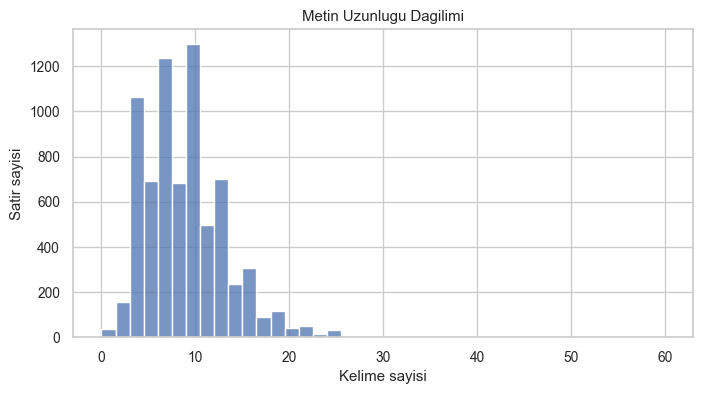

In [6]:
text_lengths = df_raw["text"].fillna("").astype(str).str.split().str.len()

print("Bos text satiri:", (df_raw["text"].str.strip() == "").sum())
print("Tam ayni text tekrar sayisi:", df_raw["text"].duplicated().sum())
print("Ortalama kelime sayisi:", round(text_lengths.mean(), 2))
print("Medyan kelime sayisi:", round(text_lengths.median(), 2))
print("Maksimum kelime sayisi:", int(text_lengths.max()))

plt.figure(figsize=(8, 4))
sns.histplot(text_lengths, bins=40)
plt.title("Metin Uzunlugu Dagilimi")
plt.xlabel("Kelime sayisi")
plt.ylabel("Satir sayisi")
plt.show()

Hedef kolon ilk 30 deger dagilimi:


,count
correct_prediction,
,1470
nörosistiserkozis,422
none,192
1,180
melanom,100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,69
Travma Sonrası Siringomyeli,65
amiloidoz,64
kimerizm,63


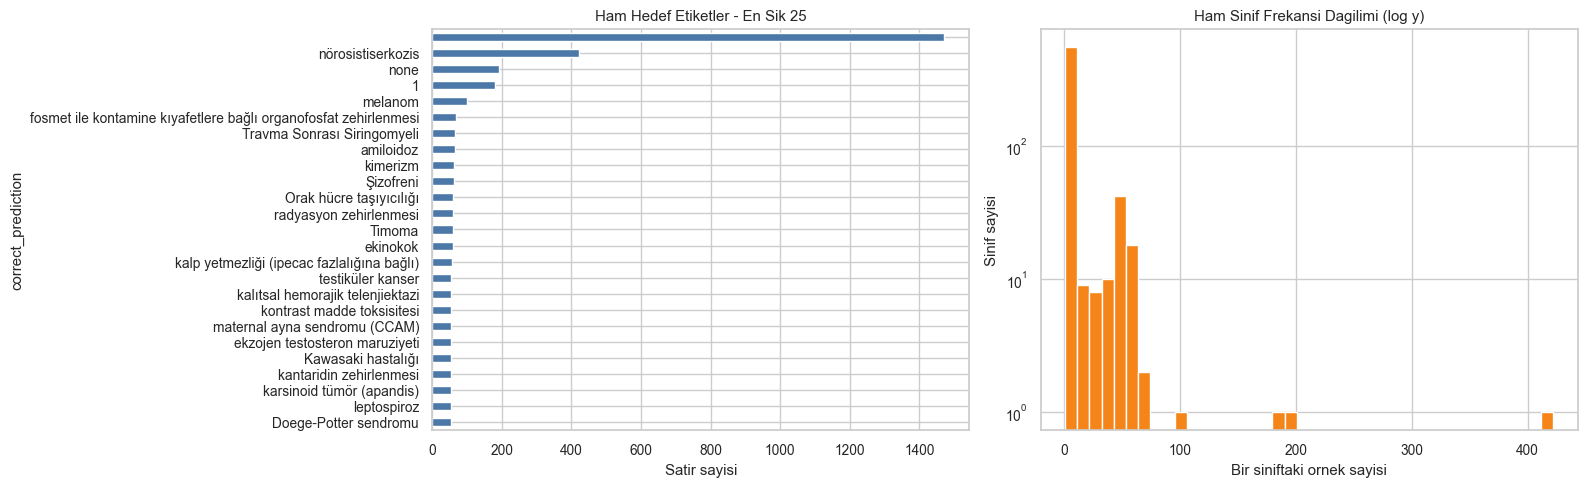

Ham hedefte bos/none/1/0 gibi gecersiz gorunen degerler modelleme oncesi filtrelenecek.


In [7]:
target_raw = df_raw[TARGET_COLUMN].fillna("").astype(str).str.strip()
raw_target_counts = target_raw.value_counts(dropna=False)

print("Hedef kolon ilk 30 deger dagilimi:")
display(raw_target_counts.head(30).to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
raw_target_counts.head(25).sort_values().plot(kind="barh", ax=axes[0], color="#4c78a8")
axes[0].set_title("Ham Hedef Etiketler - En Sik 25")
axes[0].set_xlabel("Satir sayisi")
axes[0].set_ylabel(TARGET_COLUMN)

raw_target_counts[raw_target_counts.index.astype(str).str.strip() != ""].plot(
    kind="hist",
    bins=40,
    ax=axes[1],
    color="#f58518",
    logy=True,
)
axes[1].set_title("Ham Sinif Frekansi Dagilimi (log y)")
axes[1].set_xlabel("Bir siniftaki ornek sayisi")
axes[1].set_ylabel("Sinif sayisi")
plt.tight_layout()
plt.show()

print("Ham hedefte bos/none/1/0 gibi gecersiz gorunen degerler modelleme oncesi filtrelenecek.")

## 3. Temizleme ve normalizasyon

Veri setinde Turkce karakterler, buyuk/kucuk harf farklari, bos alanlar ve bozuk JSON benzeri `medical_entities` degerleri var. Fonksiyonlar bu alanlari model icin daha kararli hale getirir.

Karakter n-gram TF-IDF kullanildigi icin yazim farklari ve eksik/bozuk kelimelere karsi model daha dayanikli olur.

In [8]:
TURKISH_CHARS = "çğıöşü"

TR_STOPWORDS = {
    "acaba", "ama", "aslında", "az", "bazı", "belki", "biri", "birkac", "birsey",
    "biz", "bu", "çok", "çünkü", "da", "daha", "de", "defa", "diye", "eğer",
    "en", "gibi", "hem", "hep", "hepsi", "her", "hiç", "için", "ile", "ise",
    "kez", "ki", "kim", "mı", "mi", "mu", "mü", "nasıl", "ne", "neden", "nerede",
    "nereye", "niçin", "niye", "o", "sanki", "şey", "siz", "şu", "tüm", "ve",
    "veya", "ya", "yani", "ben", "sen", "onlar", "bizim", "sizin", "var", "yok",
}

INVALID_LABELS = {"", "none", "nan", "1", "0", "-"}
TEXT_FEATURE_COLUMNS = ["text", "Symptom", "Test", "Drug", "Procedure", "Organ"]
META_FEATURE_COLUMNS = ["speaker", "Intent", "diagnosis_stage", "Emotion", "Sarcasm"]

# Elle kontrol edilmis, ayni taniyi yazim/ifade farkiyla temsil eden etiketler.
# Bu liste bilincli olarak dar tutuldu; farkli hastaliklari sirf benzedikleri icin birlestirmiyoruz.
LABEL_SYNONYM_MAP = {
    "wilson hastalığı tanısı": "wilson hastalığı",
    "ipecac fazlalığına bağlı": "ipecac zehirlenmesi / kalp yetmezliği",
    "kalp yetmezliği ipecac fazlalığına bağlı": "ipecac zehirlenmesi / kalp yetmezliği",
    "kalp yetmezliği / ipecac fazlalığına bağlı": "ipecac zehirlenmesi / kalp yetmezliği",
    "ipecac şurubu zehirlenmesi": "ipecac zehirlenmesi / kalp yetmezliği",
    "munchausen sendromu ve ipecac zehirlenmesi": "ipecac zehirlenmesi / kalp yetmezliği",
    "cüzzam leprozi": "cüzzam / leprozi",
    "leprozi": "cüzzam / leprozi",
    "sjogren sendromu": "sjögren sendromu",
    "fosmet ile kont m3 m82amine kıyafetlere bağlı organofosfat zehirlenmesi": "fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi",
}


def normalize_text(value):
    """Temel metin temizleme. Turkce karakterleri korur."""
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", str(value))
    text = text.lower().replace("̇", "")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(f"[^0-9a-z{TURKISH_CHARS}\s\-/+%.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_label(value):
    label = normalize_text(value)
    label = label.replace("(", " ").replace(")", " ")
    label = re.sub(r"\s*/\s*", " / ", label)
    label = re.sub(r"\s+", " ", label).strip()
    return label


def canonicalize_label(value):
    """Ayni anlama gelen hedef etiketlerini tek sinifa toplar."""
    label = normalize_label(value)
    if label in INVALID_LABELS:
        return label

    # Genel yazim sadele?tirmeleri.
    label = re.sub(r"tanısı", "", label).strip()
    label = re.sub(r"\s+", " ", label)

    if label in LABEL_SYNONYM_MAP:
        return LABEL_SYNONYM_MAP[label]

    # Bazi bozuk CSV/encoding varyantlarini hedefli olarak toparla.
    if "fosmet" in label and "organofosfat" in label:
        return "fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi"
    if "ipecac" in label:
        return "ipecac zehirlenmesi / kalp yetmezliği"
    if label in {"sjögren sendromu", "sjogren sendromu"}:
        return "sjögren sendromu"
    if label in {"cüzzam", "cüzzam leprozi", "leprozi"}:
        return "cüzzam / leprozi"

    return label


def extract_medical_entities(value):
    """JSON bozuk olsa bile medical_entities alanindan metin ve tip tokenlari cikarmaya calisir."""
    if pd.isna(value) or not str(value).strip():
        return ""

    raw = str(value).strip().replace('""', '"')
    candidates = [raw]
    if not raw.startswith("["):
        candidates.append("[" + raw)
    if not raw.endswith("]"):
        candidates.append(raw + "]")
    if not (raw.startswith("[") and raw.endswith("]")):
        candidates.append("[" + raw.strip("[]") + "]")

    for candidate in candidates:
        try:
            parsed = json.loads(candidate)
            if isinstance(parsed, dict):
                parsed = [parsed]
            tokens = []
            if isinstance(parsed, list):
                for item in parsed:
                    if isinstance(item, dict):
                        entity_text = normalize_text(item.get("text", ""))
                        entity_type = normalize_text(item.get("type", "")).replace(" ", "_")
                        if entity_text:
                            tokens.append(entity_text)
                        if entity_type:
                            tokens.append(f"entity_{entity_type}")
            if tokens:
                return " ".join(tokens)
        except Exception:
            pass

    entity_texts = re.findall(r'"text"\s*:\s*"([^"]+)"', raw)
    entity_types = re.findall(r'"type"\s*:\s*"([^"]+)"', raw)
    tokens = [normalize_text(x) for x in entity_texts]
    tokens += ["entity_" + normalize_text(x).replace(" ", "_") for x in entity_types]
    return " ".join([token for token in tokens if token])


def build_model_text(row):
    parts = []

    for col in TEXT_FEATURE_COLUMNS:
        value = normalize_text(row.get(col, ""))
        if value:
            parts.append(value)

    for col in META_FEATURE_COLUMNS:
        value = normalize_text(row.get(col, ""))
        if value:
            parts.append(f"{col.lower()}_{value.replace(' ', '_')}")

    entities = extract_medical_entities(row.get("medical_entities", ""))
    if entities:
        parts.append(entities)

    return " ".join(parts)

## 4. Modelleme veri setini hazirlama

Hedef etiket temizlenir, bos/gecersiz etiketler cikarilir, model metni olusturulur ve cok seyrek siniflar filtrelenir.

Varsayilan `MIN_CLASS_COUNT = 20`. Bu esik, her sinifta train/test bolme icin yeterli ornek kalmasina yardim eder.

In [9]:
df = df_raw.copy()
df["target_raw_clean"] = df[TARGET_COLUMN].apply(normalize_label)
df["target"] = df[TARGET_COLUMN].apply(canonicalize_label)
df["model_text"] = df.apply(build_model_text, axis=1)

before_rows = len(df)
before_valid_class_count = df.loc[~df["target_raw_clean"].isin(INVALID_LABELS), "target_raw_clean"].nunique()

df = df[(~df["target"].isin(INVALID_LABELS)) & (df["model_text"].str.len() > 0)].copy()
after_canonical_class_count = df["target"].nunique()

merge_summary = (
    df.groupby("target")
    .agg(
        row_count=("target", "size"),
        raw_label_count=("target_raw_clean", "nunique"),
        raw_labels=("target_raw_clean", lambda s: "; ".join(sorted(set(s))[:8])),
    )
    .reset_index()
    .sort_values(["raw_label_count", "row_count"], ascending=False)
)

print("Baslangic satiri:", before_rows)
print("Gecerli ham sinif sayisi:", before_valid_class_count)
print("Canonical birlestirme sonrasi sinif sayisi:", after_canonical_class_count)
print("Canonical birlestirme ile azalan sinif sayisi:", before_valid_class_count - after_canonical_class_count)
print("Bos/gecersiz hedef sonrasi satir:", len(df))
print("Birlestirilen / normalizasyonla degisen hedeflerden ornekler:")
display(merge_summary[merge_summary["raw_label_count"] > 1].head(20))

target_counts = df["target"].value_counts()
eligible_classes = target_counts[target_counts >= MIN_CLASS_COUNT].index

df_model = df[df["target"].isin(eligible_classes)].copy()
df_model = df_model.drop_duplicates(subset=["model_text", "target"]).reset_index(drop=True)

print(f"Minimum {MIN_CLASS_COUNT} ornekli siniflar sonrasi satir:", len(df_model))
print("Modelleme sinif sayisi:", df_model["target"].nunique())

display(df_model[["season", "episode", "speaker", "text", "target_raw_clean", "target", "model_text"]].head())

Baslangic satiri: 7282
Gecerli ham sinif sayisi: 633
Canonical birlestirme sonrasi sinif sayisi: 628
Canonical birlestirme ile azalan sinif sayisi: 5
Bos/gecersiz hedef sonrasi satir: 5415
Birlestirilen / normalizasyonla degisen hedeflerden ornekler:


,target,row_count,raw_label_count,raw_labels
250,ipecac zehirlenmesi / kalp yetmezliği,90,4,ipecac fazlalığına bağlı; ipecac şurubu zehirlenmesi; kalp yetmezliği ipecac fazlalığına bağlı; munchausen sendromu ve ipecac zehirlenmesi
602,wilson hastalığı,91,2,wilson hastalığı; wilson hastalığı tanısı
177,fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,70,2,fosmet ile kont+m3 m82amine kıyafetlere bağlı organofosfat zehirlenmesi; fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi


Minimum 20 ornekli siniflar sonrasi satir: 4413
Modelleme sinif sayisi: 80


,season,episode,speaker,text,target_raw_clean,target,model_text
0,1,1,Wilson,29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş.,nörosistiserkozis,nörosistiserkozis,29 yaşında bir kadın hasta ilk nöbetini bir ay önce geçirmiş. nöbet beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 nöbe...
1,1,1,Wilson,"Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.",nörosistiserkozis,nörosistiserkozis,konuşma yetisini kaybetmiş bebek gibi anlamsız sesler çıkarıyor. afazi beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 a...
2,1,1,Wilson,Mental durumu giderek kötüleşiyor.,nörosistiserkozis,nörosistiserkozis,mental durumu giderek kötüleşiyor. zihinsel durum bozukluğu beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 zihinsel dur...
3,1,1,House,Beyin tümörü dediler; ben olsam ben de o tanıyı sevmezdim. Ölecek demenin sıkıcı bir yolu.,nörosistiserkozis,nörosistiserkozis,beyin tümörü dediler ben olsam ben de o tanıyı sevmezdim. ölecek demenin sıkıcı bir yolu. beyin speaker_house intent_şaka diagnosis_stage_hipotez emotion_al...
4,1,1,Wilson,Onun yaşında beyin tümörü olması pek olası değil.,nörosistiserkozis,nörosistiserkozis,onun yaşında beyin tümörü olması pek olası değil. beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 beyin tümörü entity_di...


,target,count
0,nörosistiserkozis,422
1,melanom,100
2,wilson hastalığı,91
3,ipecac zehirlenmesi / kalp yetmezliği,90
4,fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,70
5,travma sonrası siringomyeli,65
6,amiloidoz,64
7,kimerizm,63
8,şizofreni,62
9,orak hücre taşıyıcılığı,61


Model verisi sinif min/max: 23 422
Model verisi dengesizlik orani: 18.35
En baskin sinif: nörosistiserkozis -> 422 ornek


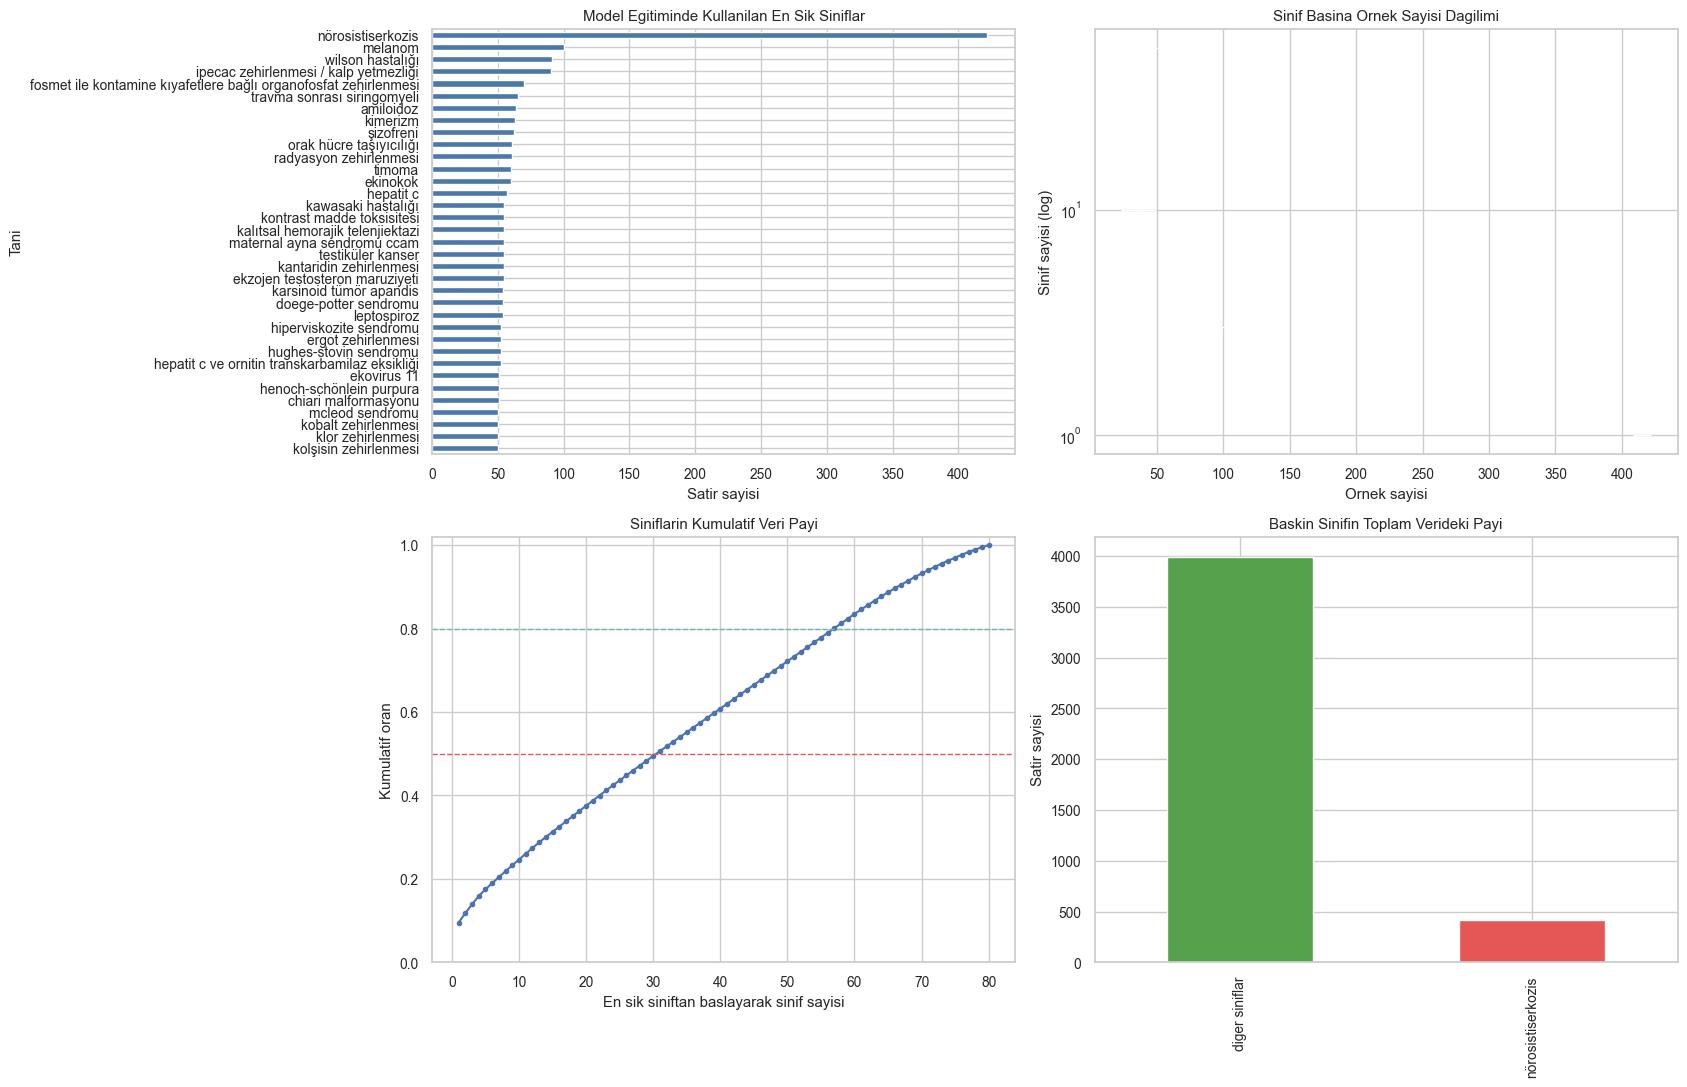

In [10]:
class_summary = df_model["target"].value_counts().rename_axis("target").reset_index(name="count")
display(class_summary.head(30))

imbalance_ratio = class_summary["count"].max() / class_summary["count"].min()
dominant_class = class_summary.iloc[0]
print("Model verisi sinif min/max:", int(class_summary["count"].min()), int(class_summary["count"].max()))
print("Model verisi dengesizlik orani:", round(imbalance_ratio, 2))
print("En baskin sinif:", dominant_class["target"], "->", int(dominant_class["count"]), "ornek")

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
class_summary.head(35).sort_values("count").plot(
    kind="barh",
    x="target",
    y="count",
    legend=False,
    ax=axes[0, 0],
    color="#4c78a8",
)
axes[0, 0].set_title("Model Egitiminde Kullanilan En Sik Siniflar")
axes[0, 0].set_xlabel("Satir sayisi")
axes[0, 0].set_ylabel("Tani")

sns.histplot(class_summary["count"], bins=30, ax=axes[0, 1], color="#f58518", log_scale=(False, True))
axes[0, 1].set_title("Sinif Basina Ornek Sayisi Dagilimi")
axes[0, 1].set_xlabel("Ornek sayisi")
axes[0, 1].set_ylabel("Sinif sayisi (log)")

sorted_counts = class_summary["count"].sort_values(ascending=False).reset_index(drop=True)
cumulative_ratio = sorted_counts.cumsum() / sorted_counts.sum()
axes[1, 0].plot(range(1, len(cumulative_ratio) + 1), cumulative_ratio, marker="o", markersize=3)
axes[1, 0].axhline(0.5, color="#e45756", linestyle="--", linewidth=1)
axes[1, 0].axhline(0.8, color="#72b7b2", linestyle="--", linewidth=1)
axes[1, 0].set_title("Siniflarin Kumulatif Veri Payi")
axes[1, 0].set_xlabel("En sik siniftan baslayarak sinif sayisi")
axes[1, 0].set_ylabel("Kumulatif oran")
axes[1, 0].set_ylim(0, 1.02)

neuro_name = "nörosistiserkozis"
focus = class_summary.copy()
focus["group"] = np.where(focus["target"] == neuro_name, neuro_name, "diger siniflar")
focus.groupby("group")["count"].sum().plot(kind="bar", ax=axes[1, 1], color=["#54a24b", "#e45756"])
axes[1, 1].set_title("Baskin Sinifin Toplam Verideki Payi")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Satir sayisi")
plt.tight_layout()
plt.show()

## 5. Train/test bolme

Stratified split kullanilir; boylece her sinifin train ve test setindeki orani mumkun oldugunca korunur.

Not: Ayni House M.D. bolumundeki satirlar ayni taniya bagli olabilir. Bu nedenle sonuc, tamamen yeni hastalik genellemesinden cok ayni veri dagilimindaki satirlari siniflandirma basarisini gosterir.

In [11]:
X = df_model["model_text"]
y = df_model["target"]
indices = df_model.index

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train satir:", len(X_train))
print("Test satir:", len(X_test))
print("Train sinif:", y_train.nunique())
print("Test sinif:", y_test.nunique())

Train satir: 3530
Test satir: 883
Train sinif: 80
Test sinif: 80


## 6. TF-IDF ozellikleri, sinif dengeleme ve model adaylari

Bu asamada uc farkli dengesizlik yaklasimi karsilastirilir:

- `class_weight="balanced"`: modelin az sinif hatalarini daha fazla cezalandirmasi.
- `median_oversample`: az siniflari train seti icinde median sinif buyuklugune kadar cogaltma.
- `augmented_balance_60`: az siniflari hafif metin augmentation ile cogaltma, cok baskin siniflari ise egitimde 60 ornege kadar kontrollu azaltma.

Dengeleme islemleri sadece train fold icinde yapilir; validation ve test setleri kesinlikle cogaltilmaz.

In [12]:
def make_features(profile="mid"):
    """TF-IDF profilleri.

    `mid` profili nadir tani terimlerini daha iyi korumak icin kelime min_df=1 kullanir,
    karakter n-gramlarini ise cok gurultu uretmemesi icin min_df=2 tutar.
    """
    if profile == "base":
        word_params = dict(ngram_range=(1, 2), min_df=2, max_df=0.95, max_features=60_000)
        char_params = dict(ngram_range=(3, 5), min_df=2, max_features=60_000)
    else:
        word_params = dict(ngram_range=(1, 3), min_df=1, max_df=0.90, max_features=120_000)
        char_params = dict(ngram_range=(2, 5), min_df=2, max_features=80_000)

    word_tfidf = TfidfVectorizer(
        lowercase=False,
        sublinear_tf=True,
        stop_words=list(TR_STOPWORDS),
        **word_params,
    )

    char_tfidf = TfidfVectorizer(
        lowercase=False,
        analyzer="char_wb",
        sublinear_tf=True,
        **char_params,
    )

    return FeatureUnion([
        ("word", word_tfidf),
        ("char", char_tfidf),
    ])


AUGMENT_SYNONYMS = {
    "nöbet": ["konvülsiyon", "atak"],
    "ağrı": ["sancı"],
    "ateş": ["yüksek ateş"],
    "kusma": ["bulantı kusma"],
    "bulantı": ["mide bulantısı"],
    "tümör": ["kitle"],
    "kanser": ["malignite"],
    "enfeksiyon": ["infeksiyon"],
    "böbrek": ["renal"],
    "karaciğer": ["hepatik"],
    "kalp": ["kardiyak"],
    "beyin": ["serebral"],
    "akciğer": ["pulmoner"],
    "zehirlenmesi": ["toksisitesi"],
}


def augment_text(text, rng):
    """Az siniflar icin hafif ve anlam bozmayacak metin varyasyonu uretir."""
    tokens = str(text).split()
    if len(tokens) < 4:
        return text

    augmented = []
    changed = False
    for token in tokens:
        replacement_options = AUGMENT_SYNONYMS.get(token)
        if replacement_options and rng.random() < 0.35:
            augmented.extend(rng.choice(replacement_options).split())
            changed = True
        elif token in TR_STOPWORDS and len(tokens) > 8 and rng.random() < 0.20:
            changed = True
            continue
        else:
            augmented.append(token)

    if len(augmented) > 6 and rng.random() < 0.30:
        pos = int(rng.integers(0, len(augmented) - 1))
        augmented[pos], augmented[pos + 1] = augmented[pos + 1], augmented[pos]
        changed = True

    if not changed and len(augmented) > 6:
        drop_pos = int(rng.integers(0, len(augmented)))
        augmented = augmented[:drop_pos] + augmented[drop_pos + 1:]

    return " ".join(augmented) if len(augmented) >= 3 else text


def balance_training_data(X, y, strategy="none", random_state=RANDOM_STATE):
    """Sadece verilen train parcasini dengeler; validation/test verisine dokunmaz."""
    data = pd.DataFrame({"text": list(X), "target": list(y)})
    if strategy in (None, "none"):
        return data["text"], data["target"]

    counts = data["target"].value_counts()
    if strategy == "median_oversample":
        target_size = int(np.ceil(counts.median()))
    elif strategy == "hybrid_q75":
        target_size = int(np.ceil(counts.quantile(0.75)))
    elif strategy == "augmented_balance_60":
        target_size = 60
    else:
        raise ValueError(f"Bilinmeyen dengeleme stratejisi: {strategy}")

    rng = np.random.default_rng(random_state)
    pieces = []
    for _, group in data.groupby("target", sort=False):
        if strategy in {"hybrid_q75", "augmented_balance_60"}:
            n_rows = target_size
        else:
            n_rows = max(len(group), target_size)

        replace = len(group) < n_rows
        sampled_idx = rng.choice(group.index.to_numpy(), size=n_rows, replace=replace)
        sampled = data.loc[sampled_idx].copy().reset_index(drop=True)

        if strategy == "augmented_balance_60" and replace:
            # Gercek ornek sayisini asan kisimlari sentetik varyasyon yaparak salt kopya etkisini azaltir.
            sampled.loc[len(group):, "text"] = sampled.loc[len(group):, "text"].apply(lambda value: augment_text(value, rng))

        pieces.append(sampled)

    balanced = pd.concat(pieces).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced["text"], balanced["target"]


def make_pipeline(feature_profile, clf):
    return Pipeline([
        ("features", make_features(feature_profile)),
        ("clf", clone(clf)),
    ])


def fit_model_spec(spec, X_fit, y_fit, random_state=RANDOM_STATE):
    X_bal, y_bal = balance_training_data(
        X_fit,
        y_fit,
        strategy=spec["resampling"],
        random_state=random_state,
    )
    model = make_pipeline(spec["features"], spec["clf"])
    model.fit(X_bal, y_bal)
    return model, len(X_bal), int(y_bal.value_counts().min()), int(y_bal.value_counts().max())


model_specs = [
    {
        "name": "Dummy Baseline",
        "features": "base",
        "resampling": "none",
        "clf": DummyClassifier(strategy="most_frequent"),
    },
    {
        "name": "ComplementNB base",
        "features": "base",
        "resampling": "none",
        "clf": ComplementNB(alpha=0.15),
    },
    {
        "name": "Linear SVM base C=0.5 class_weight",
        "features": "base",
        "resampling": "none",
        "clf": LinearSVC(C=0.5, class_weight="balanced", random_state=RANDOM_STATE, max_iter=15_000),
    },
    {
        "name": "Linear SVM mid C=1.0 class_weight",
        "features": "mid",
        "resampling": "none",
        "clf": LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=15_000),
    },
    {
        "name": "Linear SVM mid C=1.0 median oversampling",
        "features": "mid",
        "resampling": "median_oversample",
        "clf": LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=15_000),
    },
    {
        "name": "Linear SVM mid C=1.0 augmented balance 60",
        "features": "mid",
        "resampling": "augmented_balance_60",
        "clf": LinearSVC(C=1.0, class_weight=None, random_state=RANDOM_STATE, max_iter=15_000),
    },
]

for strategy in ["none", "median_oversample", "hybrid_q75", "augmented_balance_60"]:
    X_tmp, y_tmp = balance_training_data(X_train, y_train, strategy=strategy)
    print(strategy, "satir:", len(X_tmp), "sinif min/max:", int(y_tmp.value_counts().min()), int(y_tmp.value_counts().max()))

pd.DataFrame([
    {"model": spec["name"], "features": spec["features"], "resampling": spec["resampling"]}
    for spec in model_specs
])

none satir: 3530 sinif min/max: 18 337
median_oversample satir: 3746 sinif min/max: 40 337
hybrid_q75 satir: 3520 sinif min/max: 44 44
augmented_balance_60 satir: 4800 sinif min/max: 60 60


,model,features,resampling
0,Dummy Baseline,base,none
1,ComplementNB base,base,none
2,Linear SVM base C=0.5 class_weight,base,none
3,Linear SVM mid C=1.0 class_weight,mid,none
4,Linear SVM mid C=1.0 median oversampling,mid,median_oversample
5,Linear SVM mid C=1.0 augmented balance 60,mid,augmented_balance_60


## 7. Capraz dogrulama

Capraz dogrulamada dengesizlik islemi her fold'un sadece egitim parcasina uygulanir. Bu sayede validation verisi sentetik veri veya tekrarlarla kirlenmez.

In [13]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for spec in model_specs:
    print(f"Capraz dogrulama calisiyor: {spec['name']}")
    fold_rows = []

    for fold, (train_pos, valid_pos) in enumerate(cv.split(X_train, y_train), start=1):
        X_fold_train = X_train.iloc[train_pos]
        y_fold_train = y_train.iloc[train_pos]
        X_fold_valid = X_train.iloc[valid_pos]
        y_fold_valid = y_train.iloc[valid_pos]

        fitted, n_fit, fit_min, fit_max = fit_model_spec(
            spec,
            X_fold_train,
            y_fold_train,
            random_state=RANDOM_STATE + fold,
        )
        y_fold_pred = fitted.predict(X_fold_valid)

        fold_rows.append({
            "accuracy": accuracy_score(y_fold_valid, y_fold_pred),
            "balanced_accuracy": balanced_accuracy_score(y_fold_valid, y_fold_pred),
            "macro_f1": f1_score(y_fold_valid, y_fold_pred, average="macro", zero_division=0),
            "weighted_f1": f1_score(y_fold_valid, y_fold_pred, average="weighted", zero_division=0),
            "fit_rows": n_fit,
            "fit_min_class": fit_min,
            "fit_max_class": fit_max,
        })

    fold_df = pd.DataFrame(fold_rows)
    cv_rows.append({
        "model": spec["name"],
        "features": spec["features"],
        "resampling": spec["resampling"],
        "cv_accuracy_mean": fold_df["accuracy"].mean(),
        "cv_accuracy_std": fold_df["accuracy"].std(),
        "cv_balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "cv_balanced_accuracy_std": fold_df["balanced_accuracy"].std(),
        "cv_macro_f1_mean": fold_df["macro_f1"].mean(),
        "cv_macro_f1_std": fold_df["macro_f1"].std(),
        "cv_weighted_f1_mean": fold_df["weighted_f1"].mean(),
        "cv_weighted_f1_std": fold_df["weighted_f1"].std(),
        "fit_rows_mean": fold_df["fit_rows"].mean(),
        "fit_min_class_mean": fold_df["fit_min_class"].mean(),
        "fit_max_class_mean": fold_df["fit_max_class"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["cv_macro_f1_mean", "cv_balanced_accuracy_mean", "cv_weighted_f1_mean"],
    ascending=False,
)
display(cv_results)

Capraz dogrulama calisiyor: Dummy Baseline
Capraz dogrulama calisiyor: ComplementNB base
Capraz dogrulama calisiyor: Linear SVM base C=0.5 class_weight
Capraz dogrulama calisiyor: Linear SVM mid C=1.0 class_weight
Capraz dogrulama calisiyor: Linear SVM mid C=1.0 median oversampling
Capraz dogrulama calisiyor: Linear SVM mid C=1.0 augmented balance 60


,model,features,resampling,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std,fit_rows_mean,fit_min_class_mean,fit_max_class_mean
3,Linear SVM mid C=1.0 class_weight,mid,none,0.526621,0.023852,0.528443,2.949102e-02,0.517082,0.029710,0.520773,0.026447,2353.333333,12.0,224.666667
2,Linear SVM base C=0.5 class_weight,base,none,0.500561,0.018487,0.515247,2.473178e-02,0.494114,0.022169,0.496320,0.016874,2353.333333,12.0,224.666667
5,Linear SVM mid C=1.0 augmented balance 60,mid,augmented_balance_60,0.488658,0.032437,0.507582,3.506667e-02,0.489466,0.035761,0.482742,0.031343,4800.000000,60.0,60.000000
4,Linear SVM mid C=1.0 median oversampling,mid,median_oversample,0.503959,0.026183,0.497200,3.064955e-02,0.488710,0.033023,0.496862,0.027022,2513.666667,27.0,224.666667
1,ComplementNB base,base,none,0.433422,0.021110,0.417648,1.942666e-02,0.413932,0.024076,0.419537,0.022717,2353.333333,12.0,224.666667
0,Dummy Baseline,base,none,0.095468,0.000538,0.012500,2.124594e-18,0.002179,0.000011,0.016640,0.000180,2353.333333,12.0,224.666667


## 8. Test seti degerlendirmesi

Modeller train setin tamaminda egitilir ve ayrilmis test setinde olculur.

In [14]:
test_rows = []
fitted_models = {}
fit_summaries = {}

for spec in model_specs:
    print(f"Egitiliyor: {spec['name']}")
    fitted, n_fit, fit_min, fit_max = fit_model_spec(spec, X_train, y_train, random_state=RANDOM_STATE)
    y_pred = fitted.predict(X_test)
    fitted_models[spec["name"]] = fitted
    fit_summaries[spec["name"]] = {
        "fit_rows": n_fit,
        "fit_min_class": fit_min,
        "fit_max_class": fit_max,
    }

    precision, recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    test_rows.append({
        "model": spec["name"],
        "features": spec["features"],
        "resampling": spec["resampling"],
        "fit_rows": n_fit,
        "fit_min_class": fit_min,
        "fit_max_class": fit_max,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "test_weighted_f1": weighted_f1,
        "test_weighted_precision": precision,
        "test_weighted_recall": recall,
    })

test_results = pd.DataFrame(test_rows).sort_values(
    ["test_macro_f1", "test_balanced_accuracy", "test_weighted_f1"],
    ascending=False,
)
display(test_results)

best_overall = test_results.iloc[0]
balanced_candidates = test_results[test_results["resampling"].ne("none")].copy()
best_balanced = balanced_candidates.iloc[0]

if best_balanced["test_macro_f1"] >= best_overall["test_macro_f1"] - BALANCED_SELECTION_TOLERANCE:
    best_model_name = best_balanced["model"]
    selection_reason = "Dengelenmis aday en iyi genel modele cok yakin oldugu icin final model olarak secildi."
else:
    best_model_name = best_overall["model"]
    selection_reason = "Dengelenmis adaylar belirlenen toleransin gerisinde kaldigi icin en iyi genel model secildi."

best_model = fitted_models[best_model_name]
print("En iyi genel model:", best_overall["model"], "macro_f1=", round(float(best_overall["test_macro_f1"]), 4))
print("En iyi dengelenmis aday:", best_balanced["model"], "macro_f1=", round(float(best_balanced["test_macro_f1"]), 4))
print("Final secilen model:", best_model_name)
print("Secim gerekcesi:", selection_reason)
print("Fit ozeti:", fit_summaries[best_model_name])

display(balanced_candidates.head(3))

Egitiliyor: Dummy Baseline
Egitiliyor: ComplementNB base
Egitiliyor: Linear SVM base C=0.5 class_weight
Egitiliyor: Linear SVM mid C=1.0 class_weight
Egitiliyor: Linear SVM mid C=1.0 median oversampling
Egitiliyor: Linear SVM mid C=1.0 augmented balance 60


,model,features,resampling,fit_rows,fit_min_class,fit_max_class,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_weighted_precision,test_weighted_recall
3,Linear SVM mid C=1.0 class_weight,mid,none,3530,18,337,0.616082,0.609089,0.599835,0.612215,0.629505,0.616082
4,Linear SVM mid C=1.0 median oversampling,mid,median_oversample,3746,40,337,0.610419,0.597190,0.589581,0.604495,0.626162,0.610419
2,Linear SVM base C=0.5 class_weight,base,none,3530,18,337,0.576444,0.583070,0.567998,0.577321,0.606110,0.576444
5,Linear SVM mid C=1.0 augmented balance 60,mid,augmented_balance_60,4800,60,60,0.517554,0.537984,0.518233,0.514173,0.546870,0.517554
1,ComplementNB base,base,none,3530,18,337,0.490374,0.475595,0.466716,0.474744,0.498788,0.490374
0,Dummy Baseline,base,none,3530,18,337,0.096263,0.012500,0.002195,0.016906,0.009267,0.096263


En iyi genel model: Linear SVM mid C=1.0 class_weight macro_f1= 0.5998
En iyi dengelenmis aday: Linear SVM mid C=1.0 median oversampling macro_f1= 0.5896
Final secilen model: Linear SVM mid C=1.0 median oversampling
Secim gerekcesi: Dengelenmis aday en iyi genel modele cok yakin oldugu icin final model olarak secildi.
Fit ozeti: {'fit_rows': 3746, 'fit_min_class': 40, 'fit_max_class': 337}


,model,features,resampling,fit_rows,fit_min_class,fit_max_class,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_weighted_precision,test_weighted_recall
4,Linear SVM mid C=1.0 median oversampling,mid,median_oversample,3746,40,337,0.610419,0.597190,0.589581,0.604495,0.626162,0.610419
5,Linear SVM mid C=1.0 augmented balance 60,mid,augmented_balance_60,4800,60,60,0.517554,0.537984,0.518233,0.514173,0.546870,0.517554


In [15]:
y_pred_best = best_model.predict(X_test)
report_text = classification_report(y_test, y_pred_best, zero_division=0)
print(report_text)

                                                                  precision    recall  f1-score   support

                                               addison hastalığı       0.60      0.43      0.50         7
                                           afrika uyku hastalığı       0.80      0.50      0.62         8
                                                       amiloidoz       0.37      0.54      0.44        13
                                                      anafilaksi       1.00      0.40      0.57         5
                                  araknoid kist / crush sendromu       0.90      0.90      0.90        10
                                                  bakır alerjisi       0.56      0.56      0.56         9
                         balık tenyası enfeksiyonu b12 eksikliği       0.83      0.71      0.77         7
                                            chiari malformasyonu       0.33      0.40      0.36        10
                               cushing sendro

## 9. Karisiklik matrisi ve hata analizi

Sinif sayisi yuksek oldugu icin karisiklik matrisi en sik gorulen 20 sinif icin gosterilir. Daha sonra yanlis tahminlerden ornekler incelenir.

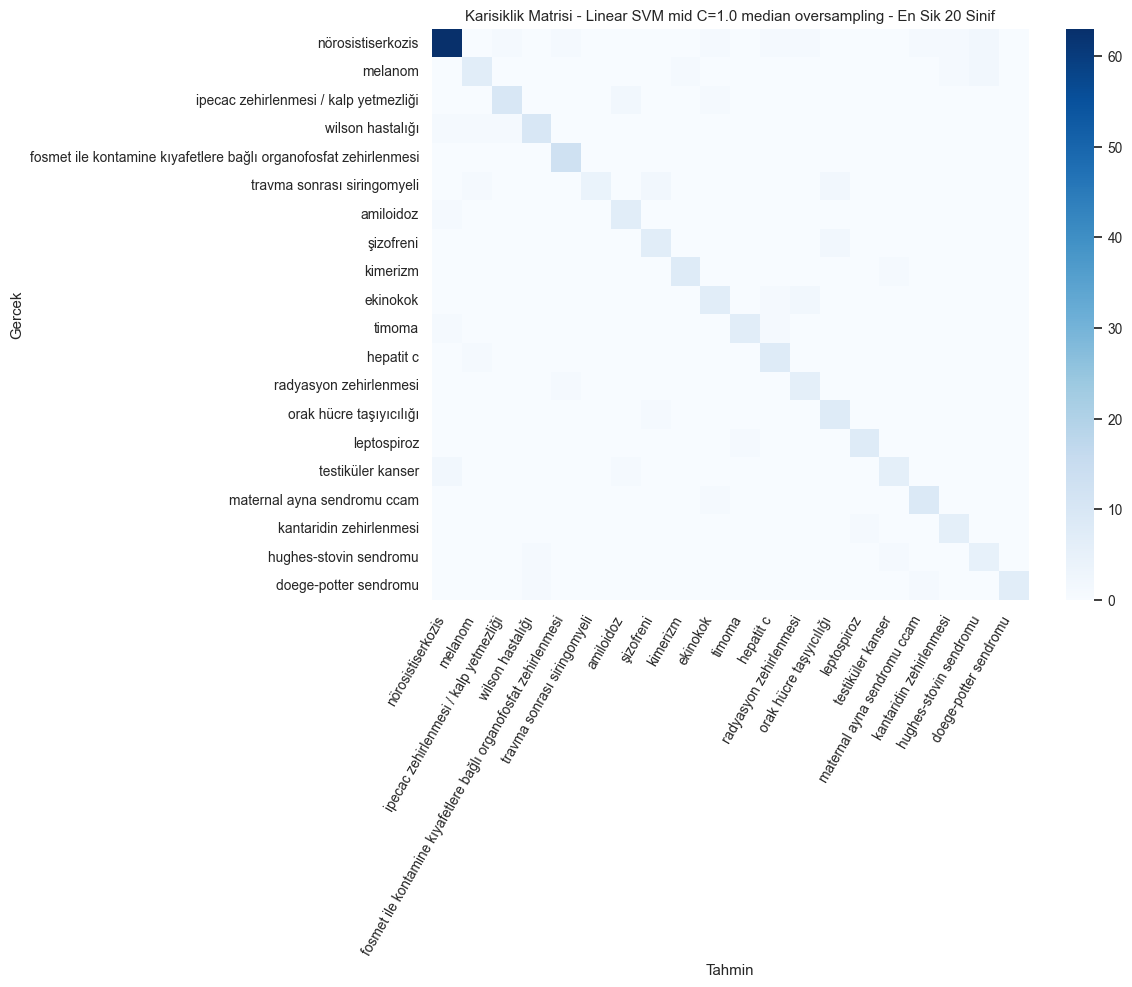

In [16]:
top_labels = y_test.value_counts().head(20).index.tolist()
cm = confusion_matrix(y_test, y_pred_best, labels=top_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=top_labels,
    yticklabels=top_labels,
)
plt.title(f"Karisiklik Matrisi - {best_model_name} - En Sik 20 Sinif")
plt.xlabel("Tahmin")
plt.ylabel("Gercek")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
error_df = df_model.loc[idx_test, [
    "season", "episode", "speaker", "text", "Symptom", "Test", "Drug", "Procedure", "Organ", "target"
]].copy()
error_df["prediction"] = y_pred_best
error_df["is_correct"] = error_df["target"].values == error_df["prediction"].values

print("Dogru tahmin orani:", round(error_df["is_correct"].mean(), 4))
print("Yanlis tahmin sayisi:", int((~error_df["is_correct"]).sum()))

display(error_df[~error_df["is_correct"]].head(20))

Dogru tahmin orani: 0.6104
Yanlis tahmin sayisi: 344


,season,episode,speaker,text,Symptom,Test,Drug,Procedure,Organ,target,prediction,is_correct
31,1,1,Foreman,Kalbini yeniden çalıştırmak için elektrik şoku vermek zorunda kaldık.,,,,defibrilasyon,kalp,nörosistiserkozis,kolşisin zehirlenmesi,False
2955,5,18,Taub,Deri testi yapalım. Alerjik reaksiyon ya da paraziter enfeksiyon olabilir.,,Test,,,,karsinoid tümör apandis,muckle-wells sendromu,False
1435,3,1,House,Bu MS değil; baş aşağı durmadan önce hiçbir semptomu yoktu.,,,,,,iskorbüt,subakut sklerozan panensefalit,False
2444,4,11,House,"Kemik iliğinden parçalar dolaşımına sızıyorlar, bu yağ embolileri böbreklerinde, akciğerlerinde ve beyninde tıkanıklığa neden oldu.","Emboli, Tıkanıklık",-,-,-,"Böbrek, Akciğer, Beyin",yağ embolisi,kızamık,False
4281,8,3,Adams,"Aritmi geri döndü, şu an Heparin alıyor ve stabil ancak bu onu inme veya emboli riskine sokabilir.",Aritmi,,Heparin,,,plummer hastalığı,intradural arteriyovenöz malformasyona bağlı omurilik basısı,False
1419,2,24,House,Metastaz belirtileri var.,,,,,,testiküler kanser,nörosistiserkozis,False
2588,5,6,House,Teşhis kesinleşti; genetik mirasları onları hem hissizleştirmiş hem de ölüme yaklaştırmış.,,,,,tüm vücut,fmf,kurşun zehirlenmesi,False
927,1,22,Chase,Toksikoloji testinde yüksek miktarda kloral hidrat bulundu.,kloral hidrat,kan testi,,,,nörosistiserkozis,fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,False
4290,8,3,House,"Çarpıntı tıbbi bir durum, kanayan kalp ise aptalca bir durum.",Çarpıntı,,,,kalp,plummer hastalığı,melanom,False
1323,2,19,Chase,Radyasyonun gecikmiş etkisi olabilir. Bazen biraz zaman alır.,,,,radyasyon,,herpes ensefaliti,kantaridin zehirlenmesi,False


## 10. Model paketini notebook icinde tutma

Kullanicinin istegi geregi bu notebook diske model, rapor veya CSV yazmaz. En iyi model ve metrikler `model_package` degiskeninde bellekte tutulur.

In [18]:
data_summary = {
    "raw_rows": int(before_rows),
    "valid_rows_after_label_text_cleaning": int(len(df)),
    "raw_valid_class_count_before_canonical_merge": int(before_valid_class_count),
    "class_count_after_canonical_merge": int(after_canonical_class_count),
    "model_rows_after_min_class_and_dedup": int(len(df_model)),
    "class_count": int(df_model["target"].nunique()),
    "min_class_count_used": int(MIN_CLASS_COUNT),
    "class_imbalance_ratio_after_filter": float(round(imbalance_ratio, 4)),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "target_column": TARGET_COLUMN,
    "selection_metric": SELECTION_METRIC,
    "balanced_selection_tolerance": float(BALANCED_SELECTION_TOLERANCE),
    "selection_reason": selection_reason,
    "balancing_methods": ["class_weight", "median_oversample", "augmented_balance_60"],
    "text_feature_columns": TEXT_FEATURE_COLUMNS,
    "meta_feature_columns": META_FEATURE_COLUMNS,
    "excluded_leakage_columns": ["correct_prediction", "model_prediction", "season", "episode"],
}

model_package = {
    "pipeline": best_model,
    "best_model_name": best_model_name,
    "target_column": TARGET_COLUMN,
    "min_class_count": MIN_CLASS_COUNT,
    "classes": sorted(df_model["target"].unique().tolist()),
    "label_synonym_map": LABEL_SYNONYM_MAP,
    "data_summary": data_summary,
    "class_summary": class_summary.to_dict(orient="records"),
    "merge_summary": merge_summary.to_dict(orient="records"),
    "cv_results": cv_results.to_dict(orient="records"),
    "test_results": test_results.to_dict(orient="records"),
    "classification_report": report_text,
}

print("Model ve metrikler yalnizca notebook belleginde hazir: model_package")
print("Disk uzerine model/rapor/CSV yazilmadi.")
display(pd.DataFrame([data_summary]))

Model ve metrikler yalnizca notebook belleginde hazir: model_package
Disk uzerine model/rapor/CSV yazilmadi.


,raw_rows,valid_rows_after_label_text_cleaning,raw_valid_class_count_before_canonical_merge,class_count_after_canonical_merge,model_rows_after_min_class_and_dedup,class_count,min_class_count_used,class_imbalance_ratio_after_filter,train_rows,test_rows,target_column,selection_metric,balanced_selection_tolerance,selection_reason,balancing_methods,text_feature_columns,meta_feature_columns,excluded_leakage_columns
0,7282,5415,633,628,4413,80,20,18.3478,3530,883,correct_prediction,macro_f1,0.015,Dengelenmis aday en iyi genel modele cok yakin oldugu icin final model olarak secildi.,"[class_weight, median_oversample, augmented_balance_60]","[text, Symptom, Test, Drug, Procedure, Organ]","[speaker, Intent, diagnosis_stage, Emotion, Sarcasm]","[correct_prediction, model_prediction, season, episode]"


## 11. Yeni metin uzerinde tahmin

Bu fonksiyon egitilmis pipeline ile yeni bir House M.D. repligi veya klinik aciklama icin tani tahmini uretir.

In [19]:

def predict_diagnosis(text, model_package=model_package):
    cleaned = normalize_text(text)
    prediction = model_package["pipeline"].predict([cleaned])[0]
    return prediction


def predict_diagnosis_from_fields(**fields):
    row = pd.Series(fields)
    model_text = build_model_text(row)
    prediction = model_package["pipeline"].predict([model_text])[0]
    return prediction

examples = [
    "Hasta n\u00f6bet gecirdi, MR goruntusunde beyinde lezyon var ve mental durum kotulesiyor.",
    "Karaciger enzimleri cok yuksek, hasta mantar ilaci sonrasi kotulesti.",
    "Gogus agrisi, kalp yetmezligi ve nefes darligi bulgulari var.",
]

for example in examples:
    print("Metin:", example)
    print("Tahmin:", predict_diagnosis(example))
    print("-" * 80)

print("Alanli ornek tahmin:")
print(predict_diagnosis_from_fields(
    text="Hasta n\u00f6bet gecirdi, MR goruntusunde beyinde lezyon var.",
    Symptom="n\u00f6bet",
    Test="MR",
    Organ="beyin",
    Intent="a\u00e7\u0131klama",
    diagnosis_stage="hipotez",
    Emotion="n\u00f6tr",
    Sarcasm="0",
))


Metin: Hasta nöbet gecirdi, MR goruntusunde beyinde lezyon var ve mental durum kotulesiyor.
Tahmin: nörosistiserkozis
--------------------------------------------------------------------------------
Metin: Karaciger enzimleri cok yuksek, hasta mantar ilaci sonrasi kotulesti.
Tahmin: veba
--------------------------------------------------------------------------------
Metin: Gogus agrisi, kalp yetmezligi ve nefes darligi bulgulari var.
Tahmin: ipecac zehirlenmesi / kalp yetmezliği
--------------------------------------------------------------------------------
Alanli ornek tahmin:
nörosistiserkozis


## Sonuc ve notlar

Bu notebook House M.D. veri setini uc asamada ele alir: veri seti hazirlama, on isleme/ozellik secimi ve modelleme. Hedef etiketlerdeki yazim farklari ve ayni taninin farkli ifadeleri `canonicalize_label` fonksiyonu ile tek sinifa indirgenir. Sinif dengesizligi ayrica grafiklerle gosterilir; ozellikle `n?rosistiserkozis` sinifinin veri setindeki baskinligi analiz edilir.

Modelleme bolumunde yalnizca accuracy kullanilmaz. Dengesiz cok sinifli problem oldugu icin `macro_f1` ve balanced accuracy ana karar metrikleri olarak kullanilir. Oversampling ve data augmentation stratejileri sadece train fold icinde uygulanir; test seti dogal dagiliminda kalir. Bu nedenle raporlanan test metrikleri gercek veri dagilimina daha yakindir.

Kullanicinin istegi geregi notebook diske model, CSV veya rapor yazmaz. En iyi model ve tum metrikler `model_package` degiskeninde bellekte tutulur.